In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os

load_dotenv()

if os.environ['GOOGLE_API_KEY']:
    print("Google API key is set")
else:
    raise ValueError("Google API key is not set")

Google API key is set


In [ ]:
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=1.0,  # Gemini 3.0+ defaults to 1.0
    max_tokens=None,
    timeout=None,
    max_retries=2,
   # other params...
)

try :
  print(model.invoke("I want to know about Langgraph ?"))
except:
  print("Something went wrong")

content='LangGraph is a library built on top of LangChain, designed for building **stateful, multi-actor applications with Large Language Models (LLMs)**.\n\nThink of it as a way to define and manage complex, iterative workflows where your AI application needs to make decisions, remember past actions, and potentially loop back or consult different "actors" (LLMs, tools, humans) based on the current state of the process.\n\n## What Problem Does LangGraph Solve?\n\nTraditional LangChain chains are often linear: input -> process A -> process B -> output. While powerful, this linear structure falls short when you need:\n\n1.  **Conditional Logic:** "If the LLM says X, do Y; otherwise, do Z."\n2.  **Loops & Cycles:** "Try generating an answer. If it\'s not good, reflect on why and try again." (Self-correction, planning, re-evaluation).\n3.  **State Management:** The application needs to remember the context, previous steps, and accumulated information as it progresses through a complex flow

### Pydantic Schema

In [5]:
from pydantic import BaseModel,Field

class graph_schema(BaseModel):
    topic : str = Field(description="The topic of the graph")
    post : str = Field(description="The LinkedIn Post Content")
    curated_post : str = Field(description="The curated LinkedIn Post Content")

demo_obj=graph_schema(topic="The importance of data privacy in the digital age",
post="Data privacy is crucial in today's digital world.With the increasing amount of personal information.",
curated_post="In the digital age, data privacy is more important than ever. With the"
)

print(demo_obj)

topic='The importance of data privacy in the digital age' post="Data privacy is crucial in today's digital world.With the increasing amount of personal information." curated_post='In the digital age, data privacy is more important than ever. With the'


In [10]:
def create_post(state: graph_schema)-> graph_schema:
#We generally refer a pydantic object using . operator like below
#    topic = state.topic

#We can also refer the pydantic model as dictionary(like we refered in 1_basics.ipynb)
    state=state.model_dump()

#Extract the topic from the state
    topic=state["topic"]

#Passing the topic to the LLM to generate a LinkedIn Post
    post=model.invoke(f"Write a LinkedIn post about {topic}").content

#Update the state with the generated post
    state['post'] = post

    return state

def curate_post(state:graph_schema)->graph_schema:
    
    post=state.post

    curated_post=model.invoke(f"Curate the following LinkedIn Post with GenZ Tone: {post}").content

    state.curated_post=curated_post

    return state

In [11]:
from langgraph.graph import StateGraph, START, END 

graph = StateGraph(graph_schema)

graph.add_node("create_post",create_post)
graph.add_node("curate_post",curate_post)

graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)



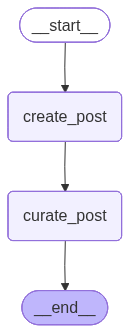

In [ ]:
from IPython.display import Image, display

my_pydantic_graph=graph.compile()

Image(my_pydantic_graph.get_graph().draw_mermaid_png())

In [14]:
my_pydantic_graph.invoke(
    {"topic":"The importance of India",
     "post":"",
     "curated_post":""
    }

)

{'topic': 'The importance of India',
 'post': "Here are a few options for a LinkedIn post about the importance of India, catering to slightly different angles. Choose the one that best fits your personal voice and focus!\n\n---\n\n**Option 1: Focus on Economic & Talent Powerhouse**\n\n🚀 **India's Ascent: An Indispensable Force in the Global Economy** 🇮🇳\n\nThe world is increasingly looking towards India, and for good reason. Its importance cannot be overstated in today's interconnected global landscape.\n\nHere's why India is a crucial player:\n\n*   **Economic Juggernaut:** As one of the fastest-growing major economies, India is a massive consumer market and a significant driver of global growth, attracting unprecedented investment.\n*   **Demographic Dividend:** With the world's largest young population, India possesses an unparalleled talent pool, particularly in STEM fields, fueling innovation and digital transformation worldwide.\n*   **Innovation Hub:** From its booming startup e